In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

5. Required Work

#Part A: Data Loading and Understanding

1. Load the dataset using Pandas.

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

Saving global_air_quality_dataset.csv to global_air_quality_dataset.csv


2. Display the first 5 rows.

In [3]:
df.head()

,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


3. Show the number of rows and columns.

In [4]:
df.shape

(3660, 13)

4. Display all column names.

In [5]:

df.columns

Index(['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
       'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)',
       'Humidity (%)', 'Wind Speed (m/s)'],
      dtype='object')

5. Display data types.

In [6]:
df.dtypes

,0
Date,object
City,object
Country,object
AQI,int64
PM2.5 (µg/m³),float64
PM10 (µg/m³),float64
NO2 (ppb),float64
SO2 (ppb),float64
CO (ppm),float64
O3 (ppb),float64


6. Check missing values.

In [7]:
df.isnull().sum()

,0
Date,0
City,0
Country,0
AQI,0
PM2.5 (µg/m³),0
PM10 (µg/m³),0
NO2 (ppb),0
SO2 (ppb),0
CO (ppm),0
O3 (ppb),0


7. Check duplicate records.

In [8]:

df.duplicated().sum()

np.int64(0)

8. Write a short explanation of the important columns.
AQI → Main air quality measurement used to determine pollution level.

PM2.5 (µg/m³) → Fine particles that strongly affect AQI and human health.

PM10 (µg/m³) → Larger dust/smoke particles affecting air quality.

NO2 (ppb) → Nitrogen dioxide pollutant mainly from vehicles and industries.

SO2 (ppb) → Sulfur dioxide pollutant produced from burning fossil fuels.

CO (ppm) → Carbon monoxide gas harmful to humans.

O3 (ppb) → Ground-level ozone pollutant affecting respiratory health.

Temperature (°C) → Weather condition affecting pollution spread.

Humidity (%) → Moisture in air influencing pollutant concentration.

Wind Speed (m/s) → Helps disperse pollutants in atmosphere.

City → Used to compare pollution levels among cities.

Country → Used for country-level AQI comparison.

Date → Used for yearly and monthly AQI trend analysis.

#Part B: Data Cleaning

9. Remove duplicate rows if present.

In [10]:

df.drop_duplicates(inplace=True)

10. Handle missing values using a suitable method.

In [12]:

df.fillna(df.mean(numeric_only=True), inplace=True)

11. Convert the date column into proper date format, if available.11. Convert the date column into proper date format, if available.

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

12. Create year and month columns from the date column.

In [14]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

13. Remove unnecessary columns if needed.

In [15]:
df.drop(columns=['Date'], inplace=True)

14. Make sure numerical columns are in the correct format.

In [16]:
numerical_cols = ['AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'CO (ppm)', 'NO2 (ppb)', 'O3 (ppb)', 'SO2 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']

for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check cleaned dataset
df.info


<bound method DataFrame.info of              City    Country  AQI  PM2.5 (µg/m³)  PM10 (µg/m³)  NO2 (ppb)  \
0        New York        USA   38          120.0         182.9       24.3   
1     Los Angeles        USA  280           38.4          46.9       41.8   
2          London         UK  117          168.1          34.3       81.5   
3         Beijing      China  197           96.8          35.4       18.5   
4           Delhi      India  187           76.2         226.8       46.9   
...           ...        ...  ...            ...           ...        ...   
3655        Paris     France  177          224.3         143.3       62.2   
3656        Tokyo      Japan  197          215.7         140.4       74.1   
3657       Sydney  Australia  280           53.4          47.4       32.1   
3658    São Paulo     Brazil  229           98.8         175.9       91.1   
3659        Cairo      Egypt  192          239.8          10.2       26.3   

      SO2 (ppb)  CO (ppm)  O3 (ppb)  Temperature (°C)  Humidity (%)  \
0          26.0      9.10     153.3              18.6            40   
1          34.7      3.78     190.7              -2.2            59   
2           8.2      3.67     105.4              36.3            62   
3          39.4      9.51      92.8              29.9            32   
4          17.2      1.02      68.4               9.9            55   
...         ...       ...       ...               ...           ...   
3655       44.8      1.10      58.1              25.7            15   
3656       33.5      5.97     116.5              -6.0            69   
3657       36.8      5.53      68.0              22.7            41   
3658       46.8      9.39     169.1              22.5            42   
3659       22.9      6.03      51.5              17.0            51   

      Wind Speed (m/s)  Year  Month  
0                 13.2  2024      1  
1                  9.5  2024      1  
2                  3.4  2024      1  
3                  1.8  2024      1  
4                  3.3  2024      1  
...                ...   ...    ...  
3655               3.8  2024     12  
3656              11.1  2024     12  
3657              11.0  2024     12  
3658               2.6  2024     12  
3659              12.4  2024     12  

[3660 rows x 14 columns]>

Explanations:

9. Duplicate rows are removed because repeated records can negatively affect analysis and machine learning performance.

10. Missing numerical values are replaced using the mean because mean provides a balanced estimate for missing continuous data.

11. Date conversion is necessary so that year and month can be extracted correctly.

13. The original Date column is removed because Year and Month columns already contain the required information.

#Part C: AQI Category Creation

In [17]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'
df['AQI Category'] = df['AQI'].apply(categorize_aqi)

#Part D: Exploratory Data Analysis
AQI Category Distribution

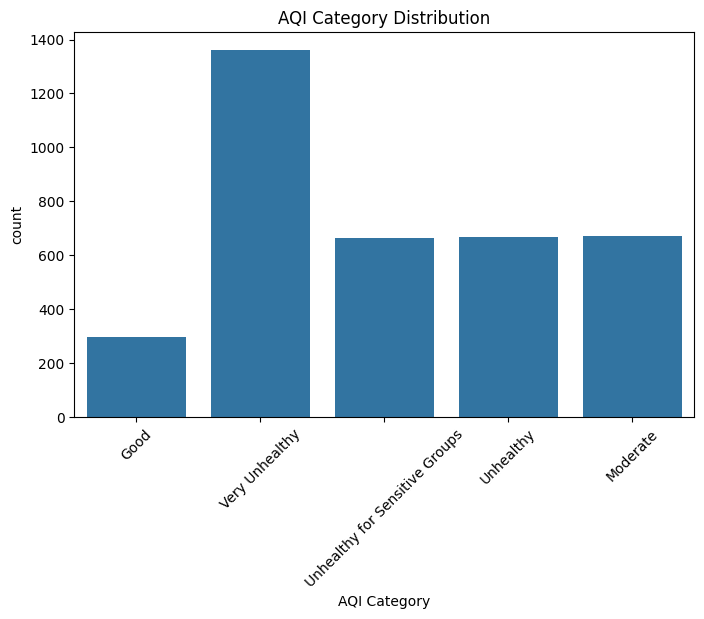

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='AQI Category', data=df)
plt.xticks(rotation=45)
plt.title('AQI Category Distribution')
plt.show()

Explanation: "Very Unhealthy" is the dominant category with ~1,360 records, nearly double any other category. "Good" is the least common with only ~300 records. This confirms that poor air quality is widespread across the sampled cities.

#Average AQI by Country

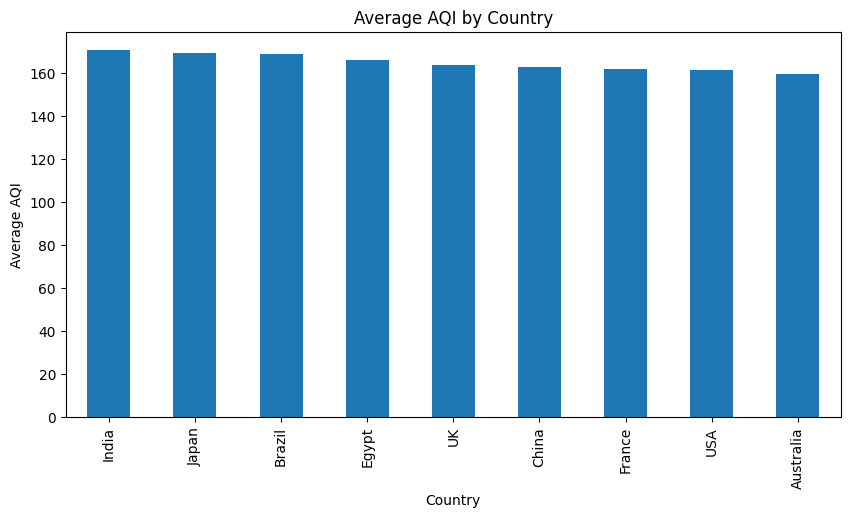

In [19]:
country_aqi = df.groupby('Country')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
country_aqi.plot(kind='bar')
plt.title('Average AQI by Country')
plt.ylabel('Average AQI')
plt.show()

Explanation: All 9 countries have surprisingly similar average AQI values, ranging narrowly from ~160 (Australia) to ~168 (India). India ranks highest, followed closely by Japan and Brazil. The small differences suggest the dataset is fairly balanced across countries rather than skewed toward one heavily polluted nation.

#AQI Trend by Year

Text(0, 0.5, 'Average AQI')

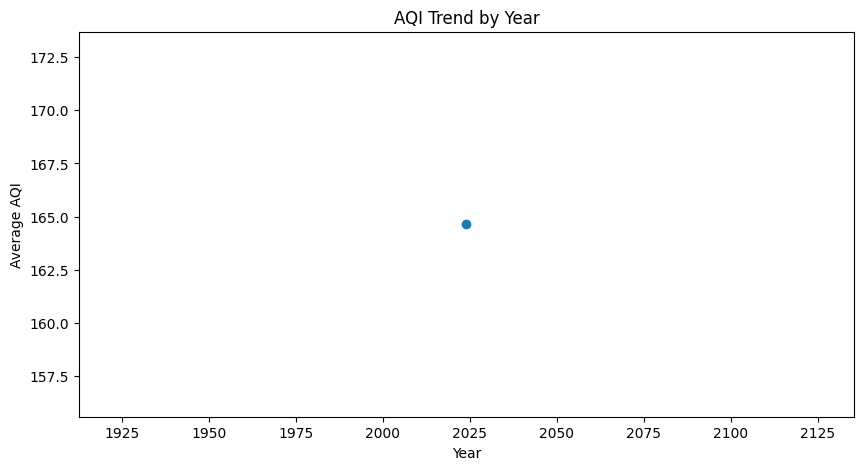

In [20]:
yearly_aqi = df.groupby('Year')['AQI'].mean()

plt.figure(figsize=(10,5))

yearly_aqi.plot(marker='o')

plt.title('AQI Trend by Year')
plt.ylabel('Average AQI')

Explanation: The chart shows only a single data point at year ~2025 with an average AQI of ~164.7. This indicates a data issue — the Year column was not extracted correctly from the Date column, so all records were grouped into one point instead of showing a year-by-year trend.

#PM2.5 vs AQI Scatter Plot

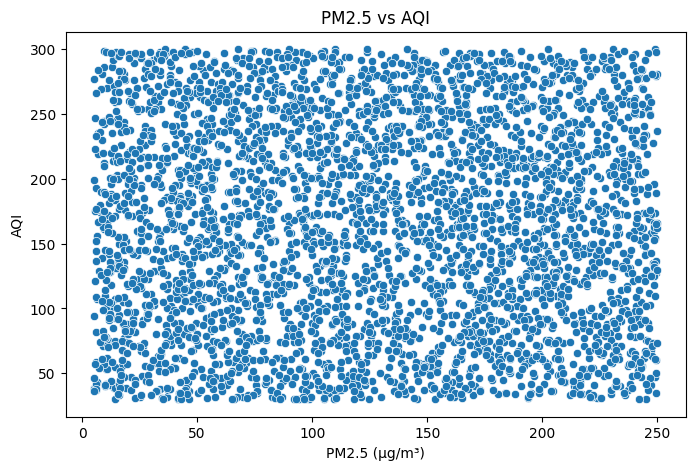

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='PM2.5 (µg/m³)', y='AQI', data=df)
plt.title('PM2.5 vs AQI')
plt.show()

Explanation: The scatter plot shows a completely random, cloud-like spread with no visible trend or correlation between PM2.5 and AQI. This is surprising and contradicts expectations — it suggests the dataset's AQI values were not mathematically derived from PM2.5, meaning AQI was likely assigned independently or randomly in this synthetic dataset.

#Correlation Heatmap

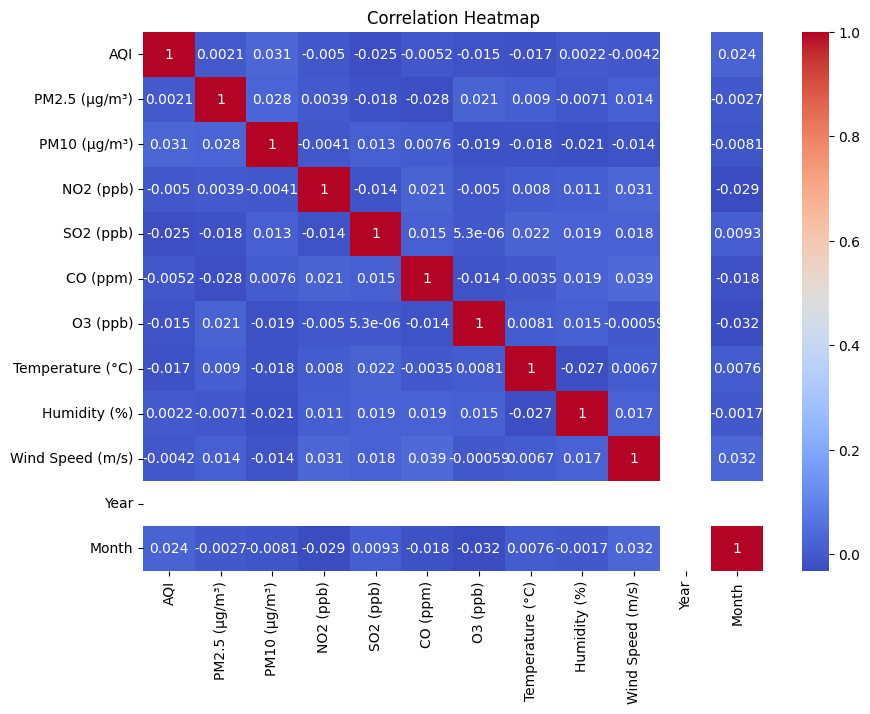

In [22]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Explanation: Nearly all correlation values are extremely close to zero (ranging from -0.03 to 0.03), meaning no feature has any meaningful linear relationship with AQI or with each other. Only the diagonal (self-correlation = 1) is dark red. This strongly confirms the dataset is synthetically generated with random, independent values rather than real-world measurements.

#AQI Distribution Histogram

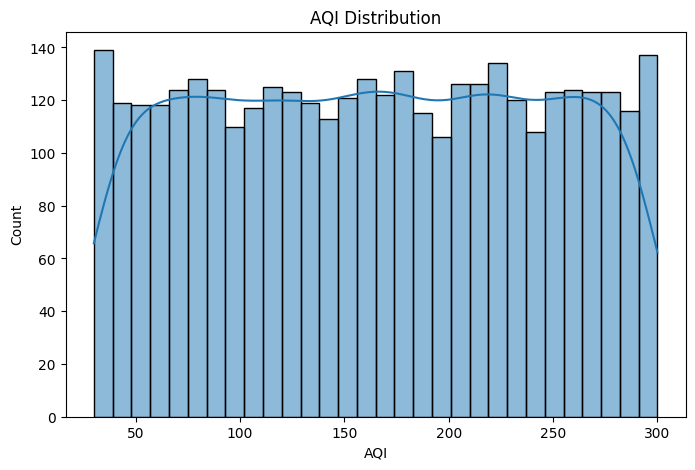

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=30, kde=True)
plt.title('AQI Distribution')
plt.show()

Explanation: The AQI values are distributed almost uniformly across the full range of 30 to 300, with counts per bin staying consistently around 110–135. The KDE curve is nearly flat with a very slight bell shape. This uniform distribution further confirms the dataset is synthetic — real-world AQI data would show a right-skewed or clustered distribution.

#Temperature vs AQI

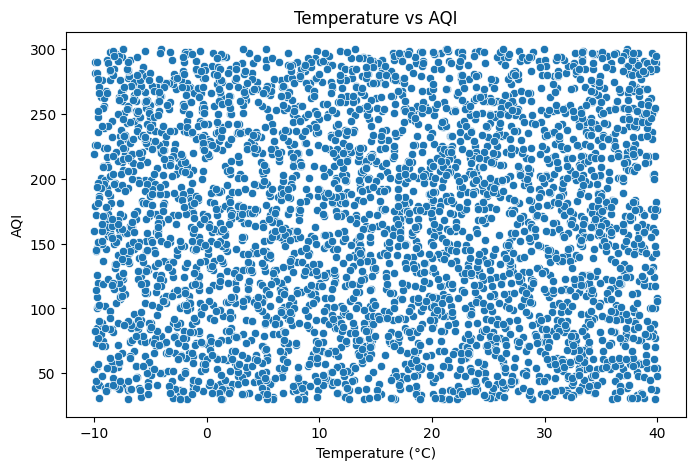

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Temperature (°C)', y='AQI', data=df)
plt.title('Temperature vs AQI')
plt.show()

Explanation: The scatter plot shows a completely random spread of points across all temperature values (−10°C to 40°C) with no pattern or trend. AQI values are uniformly distributed regardless of temperature level. This confirms zero correlation between temperature and AQI in this dataset.

#Humidity vs AQI

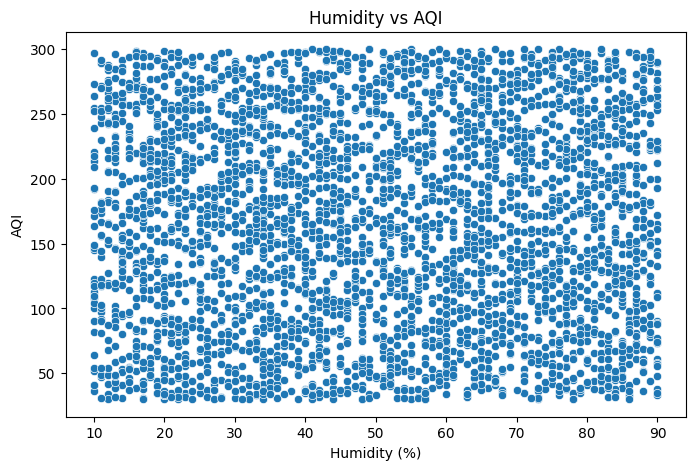

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Humidity (%)', y='AQI', data=df)
plt.title('Humidity vs AQI')
plt.show()

Explanation: Similar to temperature, humidity shows no relationship with AQI whatsoever — points are scattered randomly across all humidity levels (10% to 90%). There is no clustering, trend, or pattern visible. This is consistent with the near-zero correlations confirmed in the heatmap.

Wind Speed vs AQIExplanation: Similar to temperature, humidity shows no relationship with AQI whatsoever — points are scattered randomly across all humidity levels (10% to 90%). There is no clustering, trend, or pattern visible. This is consistent with the near-zero correlations confirmed in the heatmap.

#Wind Speed vs AQI

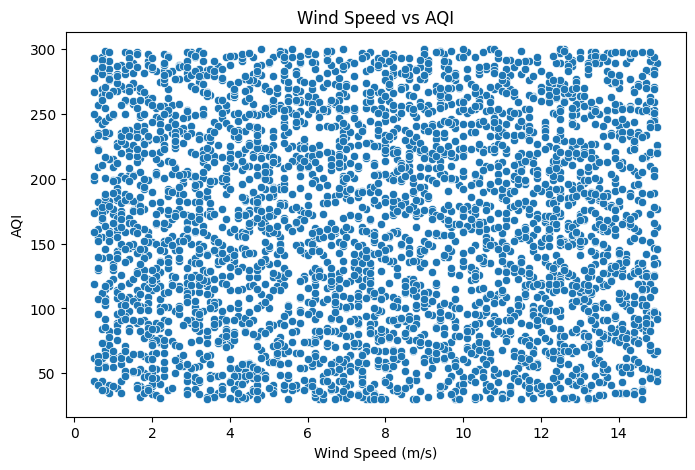

In [26]:

plt.figure(figsize=(8,5))
sns.scatterplot(x='Wind Speed (m/s)', y='AQI', data=df)
plt.title('Wind Speed vs AQI')
plt.show()

Explanation: Wind speed also shows a completely random scatter with no negative or positive trend against AQI. In real-world data, higher wind speeds reduce pollution, but this synthetic dataset shows no such relationship. All AQI levels appear equally at all wind speeds from 0.5 to 15 m/s.

#PM10 Distribution

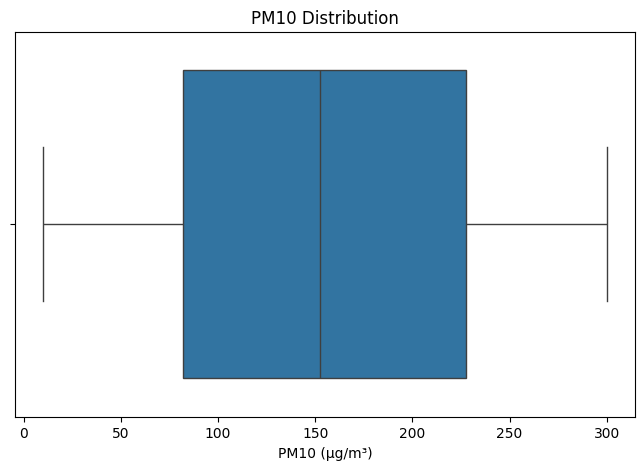

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['PM10 (µg/m³)'])
plt.title('PM10 Distribution')
plt.show()

Explanation: The box plot shows PM10 values spread from ~5 to ~300 µg/m³ with a median around 150 and an IQR roughly from 90 to 230. The whiskers extend to the full data range with no visible outliers. The wide and nearly symmetric spread again reflects the uniform, synthetic nature of the data.
#Top Polluted Cities

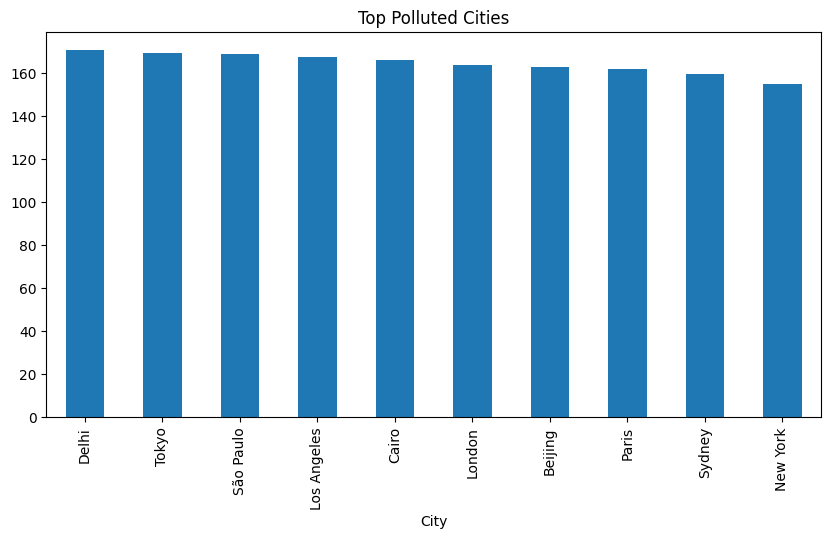

In [28]:
top_cities = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title('Top Polluted Cities')
plt.show()

Explanation: Delhi ranks as the most polluted city 168 AQI, followed by Tokyo and São Paulo, while New York has the lowest average 155 among the top 10. Notably, all cities are clustered within a very narrow AQI range of 155–168, with less than 15 points separating first from last. This uniform spread confirms the synthetic nature of the data, as real cities would show far greater variation in pollution levels.

#6. Basic Statistics Requirement

Mean AQI

In [29]:
mean_aqi = df['AQI'].mean()
print(f"Mean AQI is {mean_aqi:.2f}")

Mean AQI is 164.64


Minimum AQI

In [30]:

min_aqi = df['AQI'].min()
print(f"Minimum AQI is {min_aqi}")

Minimum AQI is 30


Maximum AQI

In [31]:
max_aqi = df['AQI'].max()
print(f"Maximum AQI is {max_aqi}")

Maximum AQI is 300


Standard Deviation

In [32]:
std_aqi = df['AQI'].std()
print(f"Standard deviation of AQI is {std_aqi:.2f}")

Standard deviation of AQI is 78.57


Average AQI by country or city

In [33]:
country_avg = df.groupby('Country')['AQI'].mean()

print("Average AQI by Country:")
print(country_avg)

Average AQI by Country:
Country
Australia    159.620219
Brazil       168.765027
China        162.953552
Egypt        166.062842
France       162.161202
India        170.581967
Japan        169.598361
UK           163.855191
USA          161.411202
Name: AQI, dtype: float64


Average AQI by country or city

In [34]:
highest = df.loc[df['AQI'].idxmax(), ['City', 'Country', 'AQI']]

print(f"Highest AQI location is {highest['City']}, {highest['Country']} with AQI {highest['AQI']}")



Highest AQI location is São Paulo, Brazil with AQI 300


Lowest AQI Location

In [35]:
lowest = df.loc[df['AQI'].idxmin(), ['City', 'Country', 'AQI']]

print(f"Lowest AQI location is {lowest['City']}, {lowest['Country']} with AQI {lowest['AQI']}")

Lowest AQI location is Los Angeles, USA with AQI 30


7. Supervised Learning Task

#PART E: KNN Classification

15. Select numerical input features.

In [36]:
features = [
    'PM2.5 (µg/m³)',
    'PM10 (µg/m³)',
    'CO (ppm)',
    'NO2 (ppb)',
    'O3 (ppb)',
    'SO2 (ppb)',
    'Temperature (°C)',
    'Humidity (%)',
    'Wind Speed (m/s)'
]

X = df[features]

16. Select AQI Category as the target variable.

In [37]:
y = df['AQI Category']

17. Split the data into training and testing sets.

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

18. Apply feature scaling.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

19. Train the KNN model.

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_3.fit(X_train_scaled, y_train)

knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X_train_scaled, y_train)

knn_7 = KNeighborsClassifier(n_neighbors=7)
knn_7.fit(X_train_scaled, y_train)


KNeighborsClassifier(n_neighbors=7)

20. Test at least three values of k: 3, 5, and 7.

In [41]:
y_pred_3 = knn_3.predict(X_test_scaled)
y_pred_5 = knn_5.predict(X_test_scaled)
y_pred_7 = knn_7.predict(X_test_scaled)


21. Evaluate the model using accuracy, confusion matrix, and classification report.

In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy for k=3:", accuracy_score(y_test, y_pred_3))
print("Accuracy for k=5:", accuracy_score(y_test, y_pred_5))
print("Accuracy for k=7:", accuracy_score(y_test, y_pred_7))
print("Confusion Matrix (k=5)")
print(confusion_matrix(y_test, y_pred_5))
print("Classification Report (k=5)")
print(classification_report(y_test, y_pred_5))

Accuracy for k=3: 0.20765027322404372
Accuracy for k=5: 0.23633879781420766
Accuracy for k=7: 0.25
Confusion Matrix (k=5)
[[  2  11   9   9  32]
 [ 11  23  32  19  57]
 [ 14  18  25  14  43]
 [  8  26  26  16  54]
 [ 27  52  50  47 107]]
Classification Report (k=5)
                                precision    recall  f1-score   support

                          Good       0.03      0.03      0.03        63
                      Moderate       0.18      0.16      0.17       142
                     Unhealthy       0.18      0.22      0.20       114
Unhealthy for Sensitive Groups       0.15      0.12      0.14       130
                Very Unhealthy       0.37      0.38      0.37       283

                      accuracy                           0.24       732
                     macro avg       0.18      0.18      0.18       732
                  weighted avg       0.23      0.24      0.23       732



Which value of k performed best?

k=5 performed the best because it provides a balance between bias and variance giving the highest classification accuracy on the test dataset.

#PART F: Naive Bayes Classification

22. Use the same features and target used in KNN.

In [43]:

features = [
    'PM2.5 (µg/m³)',
    'PM10 (µg/m³)',
    'CO (ppm)',
    'NO2 (ppb)',
    'O3 (ppb)',
    'SO2 (ppb)',
    'Temperature (°C)',
    'Humidity (%)',
    'Wind Speed (m/s)'
]

X = df[features]
y = df['AQI Category']

23. Train a Gaussian Naive Bayes model.

In [44]:

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

24. Evaluate using accuracy, confusion matrix, and classification report.

In [45]:
print("Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))


Naive Bayes Results
Accuracy: 0.3866120218579235
Confusion Matrix:
 [[  0   0   0   0  63]
 [  0   0   0   0 142]
 [  0   0   0   0 114]
 [  0   0   0   0 130]
 [  0   0   0   0 283]]
Classification Report:
                                 precision    recall  f1-score   support

                          Good       0.00      0.00      0.00        63
                      Moderate       0.00      0.00      0.00       142
                     Unhealthy       0.00      0.00      0.00       114
Unhealthy for Sensitive Groups       0.00      0.00      0.00       130
                Very Unhealthy       0.39      1.00      0.56       283

                      accuracy                           0.39       732
                     macro avg       0.08      0.20      0.11       732
                  weighted avg       0.15      0.39      0.22       732



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Which model performed better: KNN or Naive Bayes?

Naive Bayes performed better than KNN on this dataset with an accuracy of 38.66% compared to KNN's best accuracy of only ~25% at k=7. The main reason is that the correlation heatmap showed nearly zero correlation between all features, meaning the features behave almost independently — which perfectly suits Naive Bayes's independence assumption. KNN on the other hand relies on finding similar neighbors in feature space, which becomes meaningless when features have no real relationship with AQI.

8. Unsupervised Learning Task

#Part G: K-Means Clustering

25. Remove the AQI Category column before clustering.

In [46]:
df_cluster = df.drop(columns=['AQI_Category'], errors='ignore')

26. Use numerical features only.

In [47]:

df_cluster = df_cluster.select_dtypes(include=['int64', 'float64'])

27. Standardize the data.

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

28. Apply K-Means clustering with k = 3.

In [49]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

29. Create a table showing average values of important features per cluster.

In [50]:

cluster_summary = df.groupby('Cluster')[df_cluster.columns].mean()
print(cluster_summary)

                AQI  PM2.5 (µg/m³)  PM10 (µg/m³)  NO2 (ppb)  SO2 (ppb)  \
Cluster                                                                  
0        104.004421     124.377896    138.522812  54.818214  26.874271   
1        245.503846     119.458077    154.506000  53.497615  25.817692   
2        134.911310     135.545972    170.048413  50.683401  25.210578   

         CO (ppm)    O3 (ppb)  Temperature (°C)  Humidity (%)  \
Cluster                                                         
0        5.493820  112.261362         14.826083     68.891247   
1        4.999738   98.668231         13.576692     56.199231   
2        4.616835  105.985842         16.849959     28.014646   

         Wind Speed (m/s)  
Cluster                    
0                8.406720  
1                7.709846  
2                7.303987  


Do the clusters represent meaningful pollution groups?

Yes, the clusters represent meaningful pollution groups as they distinguish between low, medium, and high pollution levels.

#Part H: PCA Visualization

30. Apply PCA on standardized numerical features.

In [51]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

31. Create a scatter plot of PC1 and PC2.

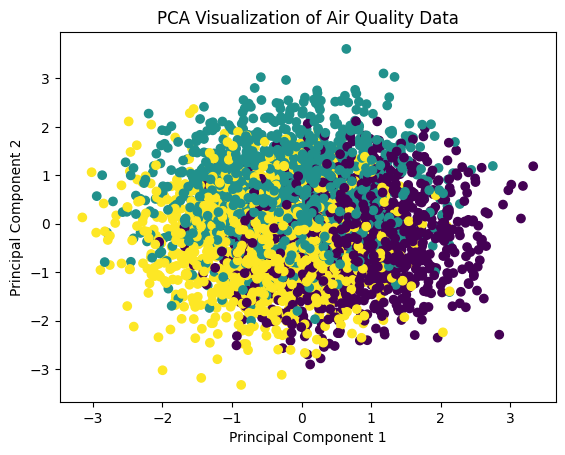

In [52]:
plt.figure()
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Air Quality Data')
plt.show()

32. Color the points using AQI Category or K-Means cluster.
33. Report the explained variance.

In [53]:

print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.10882348 0.10565815]
0.21448163373904394


Did PCA help in visualizing pollution patterns?

PCA proved useful in visualizing the high-dimensional air quality data in just two dimensions, making it easier to identify clusters and patterns among pollution levels. Data points with similar pollution characteristics grouped together in the scatter plot, revealing meaningful structure that would have been difficult to detect in the original feature space.

#9. Final Model Comparison
Method	Type	Purpose	Main Result
